# Abordagem Híbrida: Métodos Exatos + Algoritmo Genético

Este notebook implementa a seleção híbrida de meta-features combinando
soluções dos métodos exatos (MILP, Knapsack, Correlação Penalizada) com
o Algoritmo Genético via **Seeded GA** — as soluções exatas são injetadas
como indivíduos elite na população inicial do AG.

**Condições avaliadas:**
1. `all meta features` — baseline com todas as features
2. `exact-only` — apenas métodos exatos
3. `GA-only` — apenas algoritmo genético
4. `hybrid` — AG semeado com soluções exatas

## Importação das Bibliotecas
---

In [ ]:
import sys
from pathlib import Path

diretorio_atual = Path.cwd()

pasta_src = diretorio_atual / "article" / "src"

if str(pasta_src) not in sys.path:
    sys.path.append(str(pasta_src))

from metamodel import MetaModel
from genetic_selector import GeneticFeatureSelector
from ga_common import GAConfig, Score, GAResult
from hybrid_selector import (
    features_to_individual,
    run_exact_methods,
    build_seeds_from_exact,
    run_hybrid_selection,
)

In [ ]:
import os
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import wilcoxon, friedmanchisquare

warnings.filterwarnings("ignore")

## Carregamento dos Dados
---

In [48]:
meta_dataset = pd.read_csv("data/metafeatures_dataset_with_best.csv", index_col=0)

classifier_cols = [
    c for c in meta_dataset.columns
    if c in ['DecisionTree', 'SVM', 'KNN', 'LogisticRegression', 'Perceptron', 'MLP']
]
meta_feature_cols = [
    c for c in meta_dataset.columns
    if c not in ['Dataset', 'Best'] + classifier_cols
]

print(f"Datasets: {len(meta_dataset)}")
print(f"Meta-features totais: {len(meta_feature_cols)}")
print(f"Classes: {meta_dataset['Best'].nunique()}")
meta_dataset.head()

Datasets: 94
Meta-features totais: 1146
Classes: 6


,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,two_itemset.quantiles.2,two_itemset.quantiles.3,two_itemset.quantiles.4,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.727273,0.030303,0.015152,0.000000,0.045455,0.060606,0.045455,0.030303,0.000000,...,NaN,NaN,NaN,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression
1,CPMP-2015-runtime-classification_did41919,0.462121,0.219697,0.060606,0.113636,0.083333,0.030303,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.430710,0.497125,0.563630,0.563594,0.493513,0.521905,LogisticRegression
2,CastMetal1_did1447,0.439394,0.265152,0.083333,0.060606,0.045455,0.037879,0.037879,0.000000,0.000000,...,NaN,NaN,NaN,0.807459,0.859441,0.856597,0.663497,0.862378,0.871608,SVM
3,CostaMadre1_did1446,0.378788,0.121212,0.227273,0.128788,0.083333,0.015152,0.000000,0.007576,0.022727,...,NaN,NaN,NaN,0.824181,0.858136,0.861469,0.636554,0.280904,0.871638,SVM
4,Creditability-German-Credit-Data_did46416,0.522727,0.234848,0.090909,0.030303,0.007576,0.037879,0.022727,0.037879,0.007576,...,NaN,NaN,NaN,0.685000,0.648000,0.749000,0.700000,0.611000,0.711000,LogisticRegression


## Definição dos Meta-Modelos (avaliação)
---

Os mesmos meta-modelos usados no notebook de métodos exatos para garantir comparabilidade.

In [49]:
meta_models = {
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "naive_bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "svm": make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)),
    "knn": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
}

## Funções de Avaliação e Salvamento
---

Reutiliza as mesmas funções dos notebooks anteriores.

In [92]:
def save_csv(data: pd.DataFrame, name: str = "test") -> bool:
    """Salva DataFrame em CSV na pasta de resultados híbridos."""
    path = Path("results/abordagens_hibrida")
    path.mkdir(parents=True, exist_ok=True)

    try:
        data.to_csv(str(path) + f"/{name}.csv", index=False)
        return True
    except Exception as e:
        print("[Erro CSV]: ", e)
        return False

## Pré-processamento para o AG
---

O mesmo pipeline de filtragem usado no notebook de meta-heurística: filtragem não-supervisionada + Mutual Information.

In [51]:
base_config = GAConfig()

feature_cols = list(meta_feature_cols)

missing_features = [col for col in feature_cols if col not in meta_dataset.columns]
if missing_features:
    raise ValueError(f"As seguintes features não existem em meta_dataset: {missing_features}")

if base_config.target_col not in meta_dataset.columns:
    raise ValueError(f"A coluna alvo '{base_config.target_col}' não existe em meta_dataset.")

target_raw = meta_dataset[base_config.target_col].copy()
valid_target_mask = target_raw.notna()
dataset_ga = meta_dataset.loc[valid_target_mask].copy()
target_raw = dataset_ga[base_config.target_col].copy()

class_counts_before = target_raw.value_counts()
valid_classes = class_counts_before[
    class_counts_before >= base_config.min_samples_per_class
].index
rare_classes = class_counts_before[
    class_counts_before < base_config.min_samples_per_class
]
if len(rare_classes) > 0:
    print("Classes removidas por terem poucas amostras:")
    print(rare_classes)
    print("-" * 90)

dataset_ga = dataset_ga[
    dataset_ga[base_config.target_col].isin(valid_classes)
].copy()

X_df = dataset_ga[feature_cols].reset_index(drop=True)
y = dataset_ga[base_config.target_col].reset_index(drop=True)


@dataclass(frozen=True)
class FeatureFilterConfig:
    missing_threshold: float = 0.60
    quasi_constant_threshold: float = 0.98
    correlation_threshold: float = 0.985
    use_correlation_filter: bool = True


filter_config = FeatureFilterConfig()


def column_fingerprint(series):
    values = series.astype("string").fillna("__missing__")
    hashes = pd.util.hash_pandas_object(values, index=False).to_numpy(dtype=np.uint64)
    return hashlib.blake2b(hashes.tobytes(), digest_size=16).hexdigest()


def filter_features_unsupervised(X_df, config):
    X = X_df.copy()
    report = []
    initial_features = X.shape[1]

    # Valores ausentes
    missing_ratio = X.isna().mean()
    cols_high_missing = missing_ratio[missing_ratio > config.missing_threshold].index.tolist()
    X = X.drop(columns=cols_high_missing)
    report.append({"etapa": "Muitos valores ausentes", "removidas": len(cols_high_missing), "restantes": X.shape[1]})

    # Constantes
    nunique = X.nunique(dropna=True)
    cols_constant = nunique[nunique <= 1].index.tolist()
    X = X.drop(columns=cols_constant)
    report.append({"etapa": "Constantes", "removidas": len(cols_constant), "restantes": X.shape[1]})

    # Quase constantes
    cols_quasi_constant = []
    for col in X.columns:
        freq = X[col].value_counts(dropna=False, normalize=True)
        if len(freq) > 0 and freq.iloc[0] >= config.quasi_constant_threshold:
            cols_quasi_constant.append(col)
    X = X.drop(columns=cols_quasi_constant)
    report.append({"etapa": "Quase constantes", "removidas": len(cols_quasi_constant), "restantes": X.shape[1]})

    # Duplicadas
    seen = {}
    cols_duplicate = []
    for col in X.columns:
        fp = column_fingerprint(X[col])
        if fp in seen:
            s1 = X[col].astype("string").fillna("__missing__")
            s2 = X[seen[fp]].astype("string").fillna("__missing__")
            if s1.equals(s2):
                cols_duplicate.append(col)
        else:
            seen[fp] = col
    X = X.drop(columns=cols_duplicate)
    report.append({"etapa": "Duplicadas", "removidas": len(cols_duplicate), "restantes": X.shape[1]})

    # Alta correlação
    cols_correlated = []
    if config.use_correlation_filter:
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
        if len(numeric_cols) > 1:
            X_num = X[numeric_cols].copy()
            X_num = X_num.apply(pd.to_numeric, errors="coerce")
            X_num = X_num.fillna(X_num.median(numeric_only=True))
            X_num = X_num.fillna(0)
            corr = X_num.corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            cols_correlated = [col for col in upper.columns if any(upper[col] > config.correlation_threshold)]
            X = X.drop(columns=cols_correlated)
    report.append({"etapa": "Alta correlação numérica", "removidas": len(cols_correlated), "restantes": X.shape[1]})

    report_df = pd.DataFrame(report)
    removed_features = list(set(X_df.columns) - set(X.columns))

    summary = {
        "features_iniciais": initial_features,
        "features_finais": X.shape[1],
        "features_removidas": len(removed_features),
        "removed_features": removed_features,
        "report": report_df,
    }

    return X, summary


X_df, filter_summary = filter_features_unsupervised(X_df=X_df, config=filter_config)
feature_cols = list(X_df.columns)
n_total_features = len(feature_cols)

print("Resumo da filtragem inicial:")
print(filter_summary["report"])
print("-" * 90)
print(f"Features antes: {filter_summary['features_iniciais']}")
print(f"Features depois: {filter_summary['features_finais']}")
print(f"Features removidas: {filter_summary['features_removidas']}")

class_counts = y.value_counts()

if y.nunique() < 2:
    raise ValueError("Após remover classes raras, sobrou apenas uma classe em 'Best'.")

min_class_count = int(class_counts.min())
cv_splits = min(base_config.cv_splits, min_class_count)

if cv_splits < 2:
    raise ValueError("Não há amostras suficientes para validação cruzada.")

cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=base_config.random_state)

print(f"\nCV ajustado para {cv_splits} folds.")
print(f"Features totais: {n_total_features}")
print(f"Amostras usadas: {len(X_df)}")

Classes removidas por terem poucas amostras:
Best
Perceptron    1
Name: count, dtype: int64
------------------------------------------------------------------------------------------
Resumo da filtragem inicial:
                      etapa  removidas  restantes
0   Muitos valores ausentes        120       1026
1                Constantes         32        994
2          Quase constantes          8        986
3                Duplicadas          6        980
4  Alta correlação numérica         88        892
------------------------------------------------------------------------------------------
Features antes: 1146
Features depois: 892
Features removidas: 254

CV ajustado para 5 folds.
Features totais: 892
Amostras usadas: 93


## Ranking de features e filtro supervisionado
---

In [94]:
def compute_feature_ranking(X_df, y, feature_cols, random_state=42):
    rng = np.random.default_rng(random_state)
    scores = np.zeros(len(feature_cols), dtype=float)

    for i, col in enumerate(feature_cols):
        s = X_df[col]
        try:
            if pd.api.types.is_numeric_dtype(s):
                s_num = pd.to_numeric(s, errors="coerce")
                median_value = s_num.median()
                if pd.isna(median_value):
                    median_value = 0.0
                arr = s_num.fillna(median_value).to_numpy().reshape(-1, 1)
                discrete = False
            else:
                arr = (
                    s.astype("string")
                    .fillna("__missing__")
                    .astype("category")
                    .cat.codes
                    .to_numpy()
                    .reshape(-1, 1)
                )
                discrete = True

            score = mutual_info_classif(arr, y, discrete_features=discrete, random_state=random_state)[0]
            scores[i] = 0.0 if np.isnan(score) else score
        except Exception:
            scores[i] = 0.0

    ranking = np.argsort(scores)[::-1]
    if np.all(scores == 0):
        ranking = rng.permutation(len(feature_cols))

    ranking_df = pd.DataFrame({
        "feature": feature_cols,
        "filter_score": scores,
    }).sort_values("filter_score", ascending=False)

    return ranking, scores, ranking_df


feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
    X_df=X_df, y=y, feature_cols=feature_cols, random_state=base_config.random_state
)

# Filtro supervisionado (top-k por MI)
use_supervised_prefilter = True
supervised_top_k = min(150, n_total_features)

if use_supervised_prefilter:
    selected_prefilter_features = feature_ranking_df.head(supervised_top_k)["feature"].tolist()
    X_df = X_df[selected_prefilter_features].copy()
    feature_cols = list(X_df.columns)
    n_total_features = len(feature_cols)

    feature_ranking, feature_filter_scores, feature_ranking_df = compute_feature_ranking(
        X_df=X_df, y=y, feature_cols=feature_cols, random_state=base_config.random_state
    )

    print(f"Filtro supervisionado aplicado. Top-k: {supervised_top_k}")
    print(f"Features restantes: {n_total_features}")
else:
    print("Filtro supervisionado não aplicado.")

feature_ranking_df.head(20)

Filtro supervisionado aplicado. Top-k: 150
Features restantes: 150


,feature,filter_score
0,min.histogram.9,0.327880
1,median.histogram.9,0.327474
2,h_mean.histogram.9,0.324878
3,leaves,0.290867
4,var.histogram.0,0.278510
5,class_conc.histogram.0,0.266457
6,best_node.max,0.263372
7,iq_range.histogram.0,0.259687
8,mad.histogram.0,0.254818
9,elite_nn.median.relative,0.247767


In [95]:
save_csv(feature_ranking_df, "ranking_filtro_mutual_info")

True

## Pipeline do AG (estimador e construtor de pipeline)
---

In [53]:
base_estimator = ExtraTreesClassifier(
    n_estimators=180,
    max_features="sqrt",
    class_weight="balanced",
    random_state=base_config.random_state,
    n_jobs=1,
)


def build_pipeline():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, make_column_selector(dtype_include=np.number)),
            ("cat", categorical_pipeline, make_column_selector(dtype_exclude=np.number)),
        ],
        remainder="drop",
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(base_estimator)),
    ])

## Etapa 1 — Computar scores das meta-features (para métodos exatos)
---

In [54]:
meta_model_feature_scores = {}

for key, model in meta_models.items():
    meta_model = MetaModel()
    feature_scores = meta_model.meta_feature_scores(meta_dataset=meta_dataset, model=model)
    meta_model_feature_scores[key] = feature_scores

print(f"Scores computados para {len(meta_model_feature_scores)} meta-modelos.")

Scores computados para 5 meta-modelos.


## Etapa 2 — Executar métodos exatos (gerar sementes)
---

In [55]:
exact_results = run_exact_methods(
    meta_dataset=meta_dataset,
    meta_models=meta_models,
    meta_model_feature_scores=meta_model_feature_scores,
    max_feature=200,
    knapsack_lambda=0.002,
    corr_gamma=0.05,
    corr_threshold=0.3,
)

Executando métodos exatos para gerar sementes do AG híbrido

[1/3] Best Subset Selection by Filter MILP...
[2/3] Knapsack Problem ILP...
[3/3] Correlation Penalized MILP...
   -> Otimizando subconjunto para o modelo: decision_tree...
   Concluído! Selecionadas 16 features.
   -> Otimizando subconjunto para o modelo: random_forest...
   Concluído! Selecionadas 111 features.
   -> Otimizando subconjunto para o modelo: naive_bayes...
   Concluído! Selecionadas 0 features.
   -> Otimizando subconjunto para o modelo: svm...
   Concluído! Selecionadas 20 features.
   -> Otimizando subconjunto para o modelo: knn...
   Concluído! Selecionadas 71 features.

----------------------------------------------------------------------
Resumo das sementes geradas:
  Best Subset Selection by Filter MILP | decision_tree: 200 features
  Best Subset Selection by Filter MILP | random_forest: 200 features
  Best Subset Selection by Filter MILP | naive_bayes: 144 features
  Best Subset Selection by Filter MILP

## Etapa 3 — Configurações dos AGs Híbridos
---

Usamos as mesmas 3 configurações do notebook de meta-heurística, agora com sementes dos métodos exatos.

In [56]:
hard_max_features_compact = max(1, min(n_total_features, max(5, n_total_features // 8)))

# AG 1 Híbrido — Clássico binário + sementes exatas
ga_cfg_hybrid_ag1 = GAConfig(
    name="Híbrido AG 1 - Clássico binário",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=4,
    tournament_size=4,
    crossover_rate=0.85,
    mutation_start=0.10,
    mutation_end=0.02,
    init_min_prob=0.08,
    init_max_prob=0.40,
    parsimony_weight=0.04,
    parsimony_power=1.10,
    stability_weight=0.05,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.08,
    hard_max_features=None,
    initialization_strategy="random",
    crossover_mode="one_point",
    mutation_mode="flip",
    use_local_search=False,
    n_jobs=-1,
    random_state=42,
    seed_source="exact_milp_knapsack_corr",
)

# AG 2 Híbrido — Guiado por MI + busca local + sementes exatas
ga_cfg_hybrid_ag2 = GAConfig(
    name="Híbrido AG 2 - Guiado por MI + busca local",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=4,
    tournament_size=4,
    crossover_rate=0.85,
    mutation_start=0.08,
    mutation_end=0.015,
    init_min_prob=0.05,
    init_max_prob=0.30,
    parsimony_weight=0.08,
    parsimony_power=1.25,
    stability_weight=0.10,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.12,
    local_search_rounds=4,
    local_search_add_candidates=25,
    hard_max_features=None,
    initialization_strategy="guided",
    crossover_mode="uniform",
    mutation_mode="remove_bias",
    use_local_search=True,
    n_jobs=-1,
    random_state=42,
    seed_source="exact_milp_knapsack_corr",
)

# AG 3 Híbrido — Compacto/esparso + sementes exatas
ga_cfg_hybrid_ag3 = GAConfig(
    name="Híbrido AG 3 - Compacto/esparso",
    target_col=base_config.target_col,
    population_size=80,
    generations=150,
    elitism=5,
    tournament_size=5,
    crossover_rate=0.90,
    mutation_start=0.10,
    mutation_end=0.01,
    init_min_prob=0.03,
    init_max_prob=0.18,
    parsimony_weight=0.16,
    parsimony_power=1.50,
    stability_weight=0.12,
    cv_splits=cv_splits,
    scoring="accuracy",
    patience=25,
    immigrant_rate=0.15,
    local_search_rounds=5,
    local_search_add_candidates=30,
    hard_max_features=hard_max_features_compact,
    initialization_strategy="guided",
    crossover_mode="uniform",
    mutation_mode="sparse_adaptive",
    use_local_search=True,
    sparse_target_ratio=0.10,
    n_jobs=-1,
    random_state=42,
    seed_source="exact_milp_knapsack_corr",
)

hybrid_configs = [ga_cfg_hybrid_ag1, ga_cfg_hybrid_ag2, ga_cfg_hybrid_ag3]
print(f"Configurações híbridas definidas: {len(hybrid_configs)}")

Configurações híbridas definidas: 3


## Etapa 4 — Executar AG Híbrido (semeado com soluções exatas)
---

In [57]:
hybrid_results = []

for cfg in hybrid_configs:
    print(f"\nExecutando: {cfg.name}")
    result = run_hybrid_selection(
        X_df=X_df,
        y=y,
        feature_cols=feature_cols,
        feature_ranking=feature_ranking,
        pipeline_factory=build_pipeline,
        cv=cv,
        ga_config=cfg,
        exact_results=exact_results,
        n_seeds_per_method=3,
        verbose=True,
    )
    # Treinar modelo final com as features selecionadas
    final_model = build_pipeline()
    final_model.fit(X_df[result.selected_features], y)
    result.model = final_model
    hybrid_results.append(result)
    print(f"{cfg.name} concluído.\n")

print("Todos os AGs híbridos concluídos.")


Executando: Híbrido AG 1 - Clássico binário
AG Híbrido: Híbrido AG 1 - Clássico binário
Total de sementes únicas geradas: 9
Sementes injetadas na população inicial: 9
  Semente 1: 23 features ativas
  Semente 2: 59 features ativas
  Semente 3: 18 features ativas
  Semente 4: 3 features ativas
  Semente 5: 41 features ativas
  Semente 6: 62 features ativas
  Semente 7: 1 features ativas
  Semente 8: 12 features ativas
  Semente 9: 9 features ativas
----------------------------------------------------------------------
Híbrido AG 1 - Clássico binário
População: 80
Gerações máximas: 150
Scoring: accuracy
Inicialização: random
Crossover: one_point
Mutação: flip
Busca local: False
------------------------------------------------------------------------------------------
Geração 000 | Acurácia: 0.56842 ± 0.08331 | Features: 18/150 | Fitness: 0.56037 | Sem melhora: 0/25
Geração 001 | Acurácia: 0.58070 ± 0.03770 | Features: 37/150 | Fitness: 0.57024 | Sem melhora: 0/25
Geração 002 | Acurácia:

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Geração 007 | Acurácia: 0.62281 ± 0.06271 | Features: 22/150 | Fitness: 0.60927 | Sem melhora: 0/25
Geração 008 | Acurácia: 0.62281 ± 0.06271 | Features: 22/150 | Fitness: 0.60927 | Sem melhora: 1/25
Geração 009 | Acurácia: 0.62281 ± 0.06271 | Features: 22/150 | Fitness: 0.60927 | Sem melhora: 2/25
Geração 010 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 0/25
Geração 011 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 1/25
Geração 012 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 2/25
Geração 013 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 3/25
Geração 014 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 4/25
Geração 015 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 5/25
Geração 016 | Acurácia: 0.64561 ± 0.05136 | Features: 29/150 | Fitness: 0.63022 | Sem melhora: 6/25


c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

Geração 001 | Acurácia: 0.60175 ± 0.05586 | Features: 18/150 | Fitness: 0.58840 | Sem melhora: 1/25
Geração 002 | Acurácia: 0.63333 ± 0.09616 | Features: 15/150 | Fitness: 0.61674 | Sem melhora: 0/25
Geração 003 | Acurácia: 0.63333 ± 0.09616 | Features: 15/150 | Fitness: 0.61674 | Sem melhora: 1/25
Geração 004 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 0/25
Geração 005 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 1/25
Geração 006 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 2/25
Geração 007 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 3/25
Geração 008 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 4/25
Geração 009 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 5/25
Geração 010 | Acurácia: 0.64503 ± 0.04256 | Features: 18/150 | Fitness: 0.63327 | Sem melhora: 6/25


...

Geração 029 | Acurácia: 0.65614 ± 0.08421 | Features: 18/150 | Fitness: 0.63938 | Sem melhora: 9/25
Geração 030 | Acurácia: 0.65673 ± 0.06768 | Features: 18/150 | Fitness: 0.64195 | Sem melhora: 0/25
Geração 031 | Acurácia: 0.65673 ± 0.06768 | Features: 18/150 | Fitness: 0.64195 | Sem melhora: 1/25
Geração 032 | Acurácia: 0.65673 ± 0.06768 | Features: 18/150 | Fitness: 0.64195 | Sem melhora: 2/25
Geração 033 | Acurácia: 0.65673 ± 0.06768 | Features: 18/150 | Fitness: 0.64195 | Sem melhora: 3/25
Geração 034 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 0/25
Geração 035 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 1/25
Geração 036 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 2/25
Geração 037 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 3/25
Geração 038 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 4/25


c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the j

Geração 042 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 8/25
Geração 043 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 9/25
Geração 044 | Acurácia: 0.66725 ± 0.08192 | Features: 18/150 | Fitness: 0.65077 | Sem melhora: 10/25
Geração 045 | Acurácia: 0.66725 ± 0.05820 | Features: 18/150 | Fitness: 0.65362 | Sem melhora: 0/25
Geração 046 | Acurácia: 0.66725 ± 0.05820 | Features: 18/150 | Fitness: 0.65362 | Sem melhora: 1/25
Geração 047 | Acurácia: 0.66725 ± 0.05820 | Features: 18/150 | Fitness: 0.65362 | Sem melhora: 2/25
Geração 048 | Acurácia: 0.66725 ± 0.05820 | Features: 18/150 | Fitness: 0.65362 | Sem melhora: 3/25
Geração 049 | Acurácia: 0.66725 ± 0.05820 | Features: 18/150 | Fitness: 0.65362 | Sem melhora: 4/25
Geração 050 | Acurácia: 0.66725 ± 0.05820 | Features: 18/150 | Fitness: 0.65362 | Sem melhora: 5/25
Geração 051 | Acurácia: 0.67778 ± 0.06664 | Features: 18/150 | Fitness: 0.66313 | Sem melhora: 0/25

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Geração 073 | Acurácia: 0.68889 ± 0.03332 | Features: 18/150 | Fitness: 0.67824 | Sem melhora: 20/25
Geração 074 | Acurácia: 0.68889 ± 0.03332 | Features: 18/150 | Fitness: 0.67824 | Sem melhora: 21/25
Geração 075 | Acurácia: 0.68889 ± 0.03332 | Features: 18/150 | Fitness: 0.67824 | Sem melhora: 22/25
Geração 076 | Acurácia: 0.68889 ± 0.03332 | Features: 18/150 | Fitness: 0.67824 | Sem melhora: 23/25
Geração 077 | Acurácia: 0.68889 ± 0.03332 | Features: 18/150 | Fitness: 0.67824 | Sem melhora: 24/25
Geração 078 | Acurácia: 0.69942 ± 0.09858 | Features: 18/150 | Fitness: 0.68094 | Sem melhora: 0/25
Geração 079 | Acurácia: 0.69942 ± 0.09663 | Features: 18/150 | Fitness: 0.68117 | Sem melhora: 0/25
Geração 080 | Acurácia: 0.69942 ± 0.09663 | Features: 18/150 | Fitness: 0.68117 | Sem melhora: 1/25
Geração 081 | Acurácia: 0.69942 ± 0.09663 | Features: 18/150 | Fitness: 0.68117 | Sem melhora: 2/25
Geração 082 | Acurácia: 0.69942 ± 0.09663 | Features: 18/150 | Fitness: 0.68117 | Sem melhora: 

## Resultados consolidados dos AGs Híbridos
---

In [58]:
comparison_df = pd.DataFrame([
    {
        "metodo": result.name,
        "accuracy_mean": result.accuracy_mean,
        "accuracy_std": result.accuracy_std,
        "fitness": result.fitness,
        "n_features": result.n_features,
        "percentual_features": result.n_features / n_total_features,
        "features": result.selected_features,
    }
    for result in hybrid_results
]).sort_values(
    by=["accuracy_mean", "fitness", "n_features"],
    ascending=[False, False, True],
).reset_index(drop=True)

comparison_df

,metodo,accuracy_mean,accuracy_std,fitness,n_features,percentual_features,features
0,Híbrido AG 3 - Compacto/esparso,0.710526,0.095413,0.692426,18,0.120000,"[min.histogram.9, h_mean.histogram.9, var.hist..."
1,Híbrido AG 1 - Clássico binário,0.666082,0.103797,0.643323,71,0.473333,"[median.histogram.9, h_mean.histogram.9, var.h..."
2,Híbrido AG 2 - Guiado por MI + busca local,0.664912,0.108457,0.643367,30,0.200000,"[leaves, t_mean.histogram.9, sparsity.histogra..."


In [59]:
# Selecionar o melhor resultado híbrido
best_hybrid = max(
    hybrid_results,
    key=lambda r: (r.accuracy_mean, r.fitness, -r.n_features),
)

print("Melhor resultado híbrido:")
print(best_hybrid.name)
print("-" * 70)
print(f"Acurácia estimada: {best_hybrid.accuracy_mean:.5f} ± {best_hybrid.accuracy_std:.5f}")
print(f"Fitness: {best_hybrid.fitness:.5f}")
print(f"Features selecionadas: {best_hybrid.n_features}/{n_total_features}")
print("-" * 70)
print(best_hybrid.selected_features)

Melhor resultado híbrido:
Híbrido AG 3 - Compacto/esparso
----------------------------------------------------------------------
Acurácia estimada: 0.71053 ± 0.09541
Fitness: 0.69243
Features selecionadas: 18/150
----------------------------------------------------------------------
['min.histogram.9', 'h_mean.histogram.9', 'var.histogram.0', 'class_conc.histogram.0', 'best_node.max', 'mad.histogram.0', 'elite_nn.median.relative', 't_mean.histogram.9', 'worst_node.mean.relative', 'tree_depth.histogram.5', 'range.histogram.0', 'best_node.histogram.6', 'g_mean.histogram.9', 'random_node.histogram.8.relative', 'one_nn.max.relative', 'cov.histogram.0', 'cov.min', 'naive_bayes.histogram.5']


In [96]:
save_csv(comparison_df, "comparacao_algoritmos_hibridos_features")

True

## Gráficos de evolução dos AGs Híbridos
---

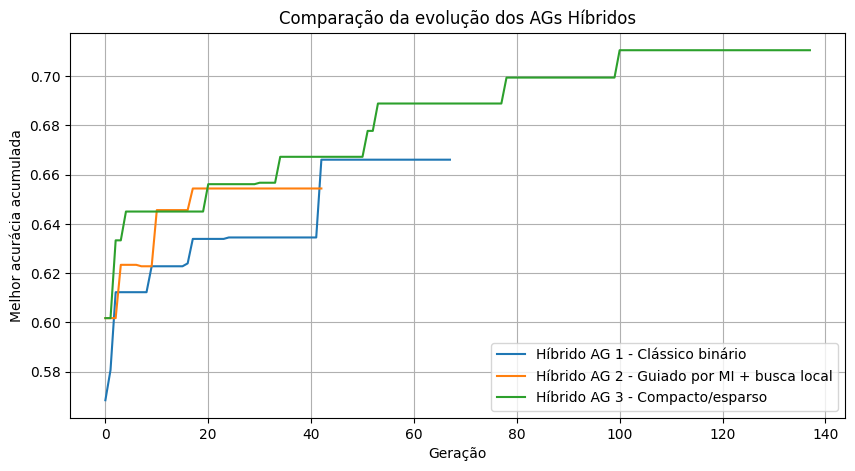

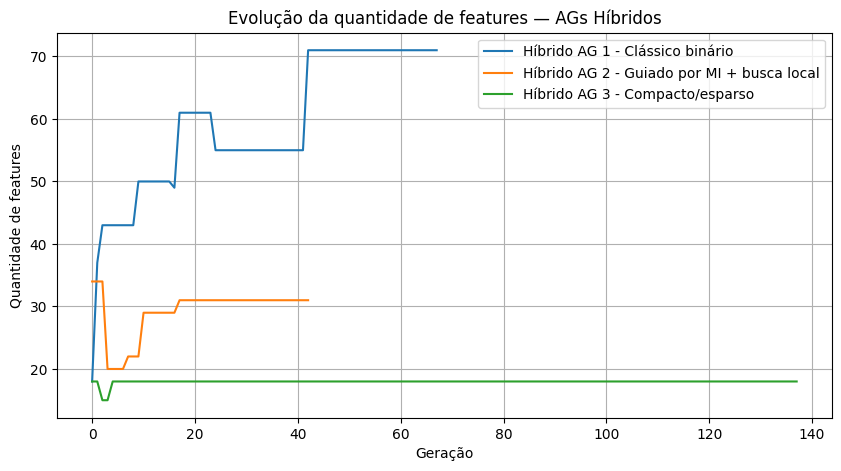

In [60]:
os.makedirs('results/plots', exist_ok=True)

# Evolução da acurácia
fig, ax = plt.subplots(figsize=(10, 5))
for result in hybrid_results:
    ax.plot(result.history["generation"], result.history["accuracy_mean"], label=result.name)
ax.set_xlabel("Geração")
ax.set_ylabel("Melhor acurácia acumulada")
ax.set_title("Comparação da evolução dos AGs Híbridos")
ax.legend()
ax.grid(True)
fig.savefig('results/plots/evolution_hybrid_accuracy.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

# Evolução do número de features
fig, ax = plt.subplots(figsize=(10, 5))
for result in hybrid_results:
    ax.plot(result.history["generation"], result.history["n_features"], label=result.name)
ax.set_xlabel("Geração")
ax.set_ylabel("Quantidade de features")
ax.set_title("Evolução da quantidade de features — AGs Híbridos")
ax.legend()
ax.grid(True)
fig.savefig('results/plots/evolution_hybrid_n_features.png', dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)

In [98]:
df_results_hybrid = pd.DataFrame(hybrid_results)
for h, name in zip(list(df_results_hybrid["model"]), list(df_results_hybrid["name"])):
    print(f"{name}: {h}")

Híbrido AG 1 - Clássico binário: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001FDBBD2BA70>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000

## Etapa — Exportação dos dataset
---

In [99]:
import os
import unidecode
import re
import scipy.sparse
from pathlib import Path

# Pasta de destino
out_path = Path("data/")
out_path.mkdir(parents=True, exist_ok=True)

for result in hybrid_results:
    # Gerar nome seguro baseado no nome da abordagem
    name_clean = unidecode.unidecode(result.name).lower()
    name_clean = re.sub(r"[^a-z0-9]+", "_", name_clean).strip("_")
    name_clean = name_clean.replace("hibrido", "hybrid")
    csv_filename = f"metafeatures_selected_with_{name_clean}.csv"
    
    # Pegar o preprocessor do pipeline ajustado
    preprocessor = result.model.named_steps["preprocessor"]
    
    # Subconjunto das features selecionadas
    X_sub = X_df[result.selected_features]
    
    # Aplicar o pré-processamento (imputação e codificação)
    X_trans = preprocessor.transform(X_sub)
    
    # Tentar recuperar os nomes das colunas após transformação
    try:
        col_names = preprocessor.get_feature_names_out()
        # Limpar os prefixos num__ e cat__ inseridos pelo ColumnTransformer
        col_names = [c.replace("num__", "").replace("cat__", "") for c in col_names]
    except AttributeError:
        col_names = [f"f_{i}" for i in range(X_trans.shape[1])]
    
    # Montar DataFrame
    if scipy.sparse.issparse(X_trans):
        df_saved = pd.DataFrame(X_trans.toarray(), columns=col_names)
    else:
        df_saved = pd.DataFrame(X_trans, columns=col_names)
    
    # Inserir Dataset e Best (target) do dataset_ga
    df_saved.insert(0, "Dataset", dataset_ga["Dataset"].values)
    df_saved.insert(1, "Best", y.values)
    
    # Salvar
    full_path = out_path / csv_filename
    df_saved.to_csv(full_path, index=False)
    print(f"Salvo: {full_path} com {len(col_names)} meta-features pré-processadas.")


Salvo: data\metafeatures_selected_with_hybrid_ag_1_classico_binario.csv com 71 meta-features pré-processadas.
Salvo: data\metafeatures_selected_with_hybrid_ag_2_guiado_por_mi_busca_local.csv com 30 meta-features pré-processadas.
Salvo: data\metafeatures_selected_with_hybrid_ag_3_compacto_esparso.csv com 18 meta-features pré-processadas.
